In [1]:
import Pkg

Pkg.activate(".")
Pkg.instantiate()
import Pkg; Pkg.add("KernelAbstractions")

  Activating project at `c:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging`
    Updating registry at `C:\Users\meghn\.julia\registries\General.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\Project.toml`
    Manifest No packages added to or removed from `C:\Users\meghn\OneDrive\Desktop\summer '26 code\ocean modeling\repo-cleanup\ocean-modeling\amazon_river\debugging\Manifest.toml`


In [2]:
using NumericalEarth
using Oceananigans
using Oceananigans.Units
using Oceananigans.Grids: node
using Oceananigans.TurbulenceClosures: IsopycnalSkewSymmetricDiffusivity, AdvectiveFormulation, VerticalScalarDiffusivity, VerticallyImplicitTimeDiscretization
using Oceananigans.Architectures: architecture
using Oceananigans.Grids: inactive_node
using Oceananigans.Operators: Azᶜᶜᵃ
using Oceananigans.Utils: launch!
using KernelAbstractions: @kernel, @index
using Dates
using Printf
using Statistics
using CUDA

In [3]:
# determining run version/params - :dye_test or :spinup
run_mode = :dye_test

use_rivers = true
resolution_tag = "trial4_8_fixed_3x3_kz1p0_mindepth30_0p1deg"

# trial 4.8: test stronger river mixing with the fixed 3x3 spread.

if run_mode == :dye_test
    run_days = 12
elseif run_mode == :spinup
    run_days = 360
else
    error("need right mode")
end

if use_rivers
    run_name = "rivers_on"
else
    run_name = "rivers_off"
end

if run_mode == :dye_test
    output_tag = "$(run_name)_dye_test_$(resolution_tag)"
else
    output_tag = "$(run_name)_spinup"
end

surface_filename = "amazon_$(output_tag)_surface_fields"
free_surface_filename = "amazon_$(output_tag)_free_surface"
dye_3d_filename = "amazon_$(output_tag)_dye_3d"
salinity_3d_filename = "amazon_$(output_tag)_salinity_3d"

checkpoint_filename = "amazon_$(run_name)_spinup_checkpoint.jld2"

"amazon_rivers_on_spinup_checkpoint.jld2"

In [4]:

arch = GPU()

# grid definitions -- amazon river mouth / plume region
long_west = -58.5
long_east = -41.5
lat_south = -7.8
lat_north = 9.2

# trial 4.8 retains the baseline 0.1-degree horizontal resolution.
# keep the 30 m minimum depth so river mixing has an active cell below.
Nx = 170
Ny = 170
Nz = 20

long_river = -49.5
lat_river  = 0.16

depth = 4000meters # decreased depth to 4k for this test 

z = ExponentialDiscretization(Nz, -depth, 0; scale = depth/4, mutable = false)
underlying_grid = LatitudeLongitudeGrid(
    arch;
    size = (Nx, Ny, Nz),
    halo = (5, 5, 4),
    longitude = (long_west, long_east),
    latitude = (lat_south, lat_north),
    z,
    topology = (Bounded, Bounded, Bounded)
)

# use at least 30 m so river-mouth columns can mix below the surface cell
bottom_height = regrid_bathymetry(underlying_grid;
                                  minimum_depth = 30,
                                  interpolation_passes = 10, 
                                  major_basins = 1) # only one major basin here -- atlantic 

grid = ImmersedBoundaryGrid(underlying_grid, GridFittedBottom(bottom_height);
                            active_cells_map=true)


                        

[ Info: Loading cached bathymetry from C:\Users\meghn\.julia\scratchspaces\904d977b-046a-4731-8b86-9235c0d1ef02\bathymetry_cache\bathymetry_170x170_-58.5_-41.5_-7.799999999999999_9.2_f6c0b31a.jld2


170×170×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5×5×4 halo:
├── immersed_boundary: GridFittedBottom(mean(z)=-1078.27, min(z)=-4000.0, max(z)=0.0)
├── underlying_grid: 170×170×20 LatitudeLongitudeGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5×5×4 halo
├── longitude: Bounded  λ ∈ [-58.5, -41.5] regularly spaced with Δλ=0.1
├── latitude:  Bounded  φ ∈ [-7.8, 9.2]    regularly spaced with Δφ=0.1
└── z:         Bounded  z ∈ [-4000.0, 0.0] variably spaced with min(Δz)=16.5232, max(Δz)=738.605

In [5]:

# trial 4.8 keeps the original ordinary gm/redi closure.
eddy_closure = IsopycnalSkewSymmetricDiffusivity(
    κ_skew = 1e3,
    κ_symmetric = 1e3,
    skew_flux_formulation = AdvectiveFormulation()
)

vertical_mixing = NumericalEarth.Oceans.default_ocean_closure()

# add extra vertical tracer mixing near the river mouth and above 30 meters
const river_mixing_longitude = -49.35
const river_mixing_latitude = -0.15
const river_mixing_kz = 1.0
const river_mixing_depth = 30meters
const river_mixing_half_width = 0.25

@inline function river_mouth_kz(longitude, latitude, z, time)
    inside_longitude = abs(longitude - river_mixing_longitude) <= river_mixing_half_width
    inside_latitude = abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    inside_depth = z >= -river_mixing_depth

    if inside_longitude && inside_latitude && inside_depth
        return river_mixing_kz
    else
        return 0.0
    end
end

river_mixing = VerticalScalarDiffusivity(
    VerticallyImplicitTimeDiscretization();
    κ = (T = river_mouth_kz,
         S = river_mouth_kz,
         dye = river_mouth_kz,
         e = 0.0)
)

closure = (eddy_closure, vertical_mixing, river_mixing)

(IsopycnalSkewSymmetricDiffusivity:
├── κ_skew: 1000.0
├── κ_symmetric: 1000.0
├── isopycnal_tensor: Oceananigans.TurbulenceClosures.SmallSlopeIsopycnalTensor{Float64}
└── slope_limiter: Oceananigans.TurbulenceClosures.FluxTapering{Float64}, CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
├── maximum_tracer_diffusivity: Inf
├── maximum_tke_diffusivity: Inf
├── maximum_viscosity: Inf
├── minimum_tke: 1.0e-9
├── negative_tke_time_scale: 60.0
├── minimum_convective_buoyancy_flux: 1.0e-11
├── tke_time_step: Nothing
├── mixing_length: TKEBasedVerticalDiffusivities.CATKEMixingLength
│   ├── Cˢ:   1.131
│   ├── Cᵇ:   0.01
│   ├── Cʰⁱu: 0.242
│   ├── Cʰⁱc: 0.098
│   ├── Cʰⁱe: 0.548
│   ├── Cˡᵒu: 0.361
│   ├── Cˡᵒc: 0.369
│   ├── Cˡᵒe: 7.863
│   ├── Cᵘⁿu: 0.37
│   ├── Cᵘⁿc: 0.572
│   ├── Cᵘⁿe: 1.447
│   ├── Cᶜu:  3.705
│   ├── Cᶜc:  4.793
│   ├── Cᶜe:  3.642
│   ├── Cᵉc:  0.112
│   ├── Cᵉe:  0.0
│   ├── Cˢᵖ:  0.505
│   ├── CRiᵟ: 1.02
│   └── CRi⁰: 0.254
└── turbulent_kinetic_ener

In [6]:
free_surface = SplitExplicitFreeSurface(grid; substeps = 70)
momentum_advection = WENOVectorInvariant(order = 5)
tracer_advection = WENO(order = 5)

# create zero-gradient (neumann) boundary conditions for dye 
# "flow out" part of the model 
dye_bcs = FieldBoundaryConditions(
    west   = GradientBoundaryCondition(0),
    east   = GradientBoundaryCondition(0),
    south  = GradientBoundaryCondition(0),
    north  = GradientBoundaryCondition(0),
    top    = FluxBoundaryCondition(0),
    bottom = FluxBoundaryCondition(0)
)

# compile tracer boundary conditions for the model
model_bcs = (
    dye = dye_bcs,
)

# updated sponge layer logic!
# summary: inital sponge was too large + errored. kept on throwing invalidireerror. oceanangians converts the sponge relaxation into a continuous form, which isn't compatible with the gpu, hence the error
# made a manual function creating the gaussian mask for the northern bounday, but then applied the relaxation in discrete form 

# store as gpu-accessible constant
const north_sponge_mask = GaussianMask{:y}(
    center = 9.2,
    width = 0.25
)

# store as a gpu-accessible constant
const north_sponge_rate = 1 / 5days

# apply gaussian dye relaxation in discrete form
@inline function north_dye_sponge(i, j, k, grid, clock, model_fields)
    # get the coordinates of dye cell
    x, y, z = node(i, j, k, grid, Center(), Center(), Center())

    # evaluate gaussian mask from oceaningans at this cell
    mask = north_sponge_mask(x, y, z)

    # read the local dye concentration + relax towards 0 
    dye = @inbounds model_fields.dye[i, j, k]
    return -north_sponge_rate * mask * dye

end

# use the discrete form to avoid the bug 
dye_sponge = Forcing(
    north_dye_sponge;
    discrete_form = true
)

# apply the sponge only to dye
model_forcing = (
    dye = dye_sponge,
)
                        
# dd dye with the original numericalearth momentum, tracer, and closure settings.
ocean = ocean_simulation(grid;
                         momentum_advection, tracer_advection, free_surface,
                         closure = closure,
                         tracers = (:T, :S, :dye),
                         boundary_conditions = model_bcs,
                         forcing = model_forcing
                         )

# instead of floating dye patch, new dye patch centered on the river mouth, fading with distance
# dye is initially deposited only in the upper 10 meters
@inline function dye_initial_condition(x, y, z)
    horizontal_width = 0.5

    horizontal_blob = exp(-((x - long_river)^2 + (y - lat_river)^2) / horizontal_width^2)

    if z > -10
        return horizontal_blob
    else
        return 0
    end
end

# print the model structure so we can check that dye is listed as a tracer and that the boundary conditions were set to 0 gradient
@info "We've built an ocean simulation with model:"
@show ocean.model
@show ocean.model.tracers.dye.boundary_conditions



[ Info: We've built an ocean simulation with model:


ocean.model = HydrostaticFreeSurfaceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── grid: 170×170×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5×5×4 halo
├── timestepper: SplitRungeKuttaTimeStepper
├── tracers: (T, S, dye, e)
├── closure: Tuple with 3 closures:
│   ├── CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
│   ├── IsopycnalSkewSymmetricDiffusivity(κ_skew=1000.0, κ_symmetric=1000.0)
│   └── VerticalScalarDiffusivity{VerticallyImplicitTimeDiscretization}(ν=0.0, κ=(T=river_mouth_kz (generic function with 1 method), S=river_mouth_kz (generic function with 1 method), dye=river_mouth_kz (generic function with 1 method), e=0.0))
├── buoyancy: SeawaterBuoyancy with g=9.80665 and BoussinesqEquationOfState{Float64} with ĝ = NegativeZDirection()
├── free surface: SplitExplicitFreeSurface with gravitational acceleration 9.80665 m s⁻²
│   └── substepping: FixedSubstepNumber(50)
├── advection scheme: 
│   ├── momentum

Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: GradientBoundaryCondition: 0.0
├── east: GradientBoundaryCondition: 0.0
├── south: GradientBoundaryCondition: 0.0
├── north: GradientBoundaryCondition: 0.0
├── bottom: FluxBoundaryCondition: 0.0
├── top: FluxBoundaryCondition: 0.0
└── immersed: FluxBoundaryCondition: Nothing

In [7]:
# ask for ecco credentials at runtime so they are not saved in the notebook
ENV["ECCO_USERNAME"] = "meggoeggo"
ENV["ECCO_WEBDAV_PASSWORD"] = "3a0bqyAsTojLw4ZtpKaC"


date = DateTime(1993, 1, 1)

ecco_variables = (:temperature, :salinity)
ecco_set = MetadataSet(ecco_variables; dataset = ECCO4Monthly(), date)

# we aren't initializing the tracer just yet (first spinning-up the model for a year)  
# print out all of the tracers 
set!(ocean.model, ecco_set)
@show keys(ocean.model.tracers)

keys(ocean.model.tracers) = (:T, :S, :dye, :e)


(:T, :S, :dye, :e)

In [8]:

land = JRA55PrescribedLand(arch)
atmosphere = JRA55PrescribedAtmosphere(arch)
ocean_surface = SurfaceRadiationProperties(albedo = LatitudeDependentAlbedo())
radiation = JRA55PrescribedRadiation(arch; ocean_surface)

640×320×1×2920 PrescribedRadiation on LatitudeLongitudeGrid:
├── times: 2920-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
├── stefan_boltzmann_constant: 5.67037e-8
└── surface_properties: (:ocean, :sea_ice)

In [9]:
# trial 4.8 spreads river water over a fixed 3x3 neighborhood on the gpu
const interface_computations = NumericalEarth.EarthSystemModels.InterfaceComputations
const river_spread_radius = Ref(1)

struct RiverSpread{F, A, M, C}
    raw_flux :: F
    surface_area :: A
    mixing_ready :: M
    recipient_count :: C
end

# save surface area and whether the column has a second active layer
@kernel function save_river_cells!(surface_area, mixing_ready, grid)
    i, j = @index(Global, NTuple)
    k = grid.Nz
    surface_active = !inactive_node(i, j, k, grid, Center(), Center(), Center())
    below_active = !inactive_node(i, j, k - 1, grid, Center(), Center(), Center())
    longitude, latitude, z = node(i, j, k, grid, Center(), Center(), Center())
    inside_longitude = abs(longitude - river_mixing_longitude) <= river_mixing_half_width
    inside_latitude = abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    inside_mixing_box = inside_longitude && inside_latitude

    if surface_active
        @inbounds surface_area[i, j, 1] = Azᶜᶜᵃ(i, j, k, grid)
    else
        @inbounds surface_area[i, j, 1] = 0
    end

    if surface_active && below_active && inside_mixing_box
        @inbounds mixing_ready[i, j, 1] = 1
    else
        @inbounds mixing_ready[i, j, 1] = 0
    end
end

# count each source cell's possible destinations once
@kernel function count_river_targets!(recipient_count, surface_area, mixing_ready, Nx, Ny, radius)
    i, j = @index(Global, NTuple)
    source_area = @inbounds surface_area[i, j, 1]

    if source_area > 0
        active_neighbors = 0
        ready_neighbors = 0
        for neighbor_i in max(1, i - radius):min(Nx, i + radius)
            for neighbor_j in max(1, j - radius):min(Ny, j + radius)
                neighbor_area = @inbounds surface_area[neighbor_i, neighbor_j, 1]
                if neighbor_area > 0
                    active_neighbors += 1
                end

                neighbor_ready = @inbounds mixing_ready[neighbor_i, neighbor_j, 1] > 0
                if neighbor_ready
                    ready_neighbors += 1
                end
            end
        end

        if ready_neighbors > 0
            @inbounds recipient_count[i, j, 1] = ready_neighbors
        else
            @inbounds recipient_count[i, j, 1] = -active_neighbors
        end
    else
        @inbounds recipient_count[i, j, 1] = 0
    end
end

# give each source cell's water to nearby columns where mixing can act
@kernel function spread_river_water!(spread_flux, raw_flux, surface_area, mixing_ready, recipient_count, Nx, Ny, radius)
    i, j = @index(Global, NTuple)
    destination_area = @inbounds surface_area[i, j, 1]
    destination_ready = @inbounds mixing_ready[i, j, 1] > 0
    transported_mass = zero(eltype(spread_flux))

    if destination_area > 0
        for source_i in max(1, i - radius):min(Nx, i + radius)
            for source_j in max(1, j - radius):min(Ny, j + radius)
                source_area = @inbounds surface_area[source_i, source_j, 1]

                if source_area > 0
                    stored_count = @inbounds recipient_count[source_i, source_j, 1]
                    destination_accepts = destination_ready
                    number_of_recipients = stored_count
                    if stored_count < 0
                        destination_accepts = true
                        number_of_recipients = -stored_count
                    end

                    if destination_accepts && number_of_recipients > 0
                        source_flux = @inbounds raw_flux[source_i, source_j, 1]
                        transported_mass += source_flux * source_area / number_of_recipients
                    end
                end
            end
        end

        @inbounds spread_flux[i, j, 1] = transported_mass / destination_area
    else
        @inbounds spread_flux[i, j, 1] = zero(eltype(spread_flux))
    end
end

function RiverSpread(grid)
    raw_flux = Field{Center, Center, Nothing}(grid)
    surface_area = Field{Center, Center, Nothing}(grid)
    mixing_ready = Field{Center, Center, Nothing}(grid)
    recipient_count = Field{Center, Center, Nothing}(grid)
    launch!(architecture(grid), grid, :xy, save_river_cells!, surface_area, mixing_ready, grid)
    return RiverSpread(raw_flux, surface_area, mixing_ready, recipient_count)
end

# save the original flux, then replace it with the spread flux
function interface_computations.correct_state!(correction::RiverSpread, exchanger, grid)
    freshwater_flux = exchanger.state.freshwater_flux
    copyto!(parent(correction.raw_flux.data), parent(freshwater_flux.data))
    radius = river_spread_radius[]
    launch!(architecture(grid), grid, :xy, count_river_targets!,
            correction.recipient_count, correction.surface_area, correction.mixing_ready,
            grid.Nx, grid.Ny, radius)
    launch!(architecture(grid), grid, :xy, spread_river_water!,
            freshwater_flux, correction.raw_flux, correction.surface_area, correction.mixing_ready, correction.recipient_count,
            grid.Nx, grid.Ny, radius)
    return nothing
end

# attach this correction when numericalearth makes the land exchange field
function interface_computations.ComponentExchanger(::PrescribedLand, grid)
    state = (; freshwater_flux = Field{Center, Center, Nothing}(grid))
    correction = RiverSpread(grid)
    return interface_computations.ComponentExchanger(state, nothing, correction)
end

In [10]:
# trial 4.8 requires the river freshwater forcing
@assert use_rivers "trial 4.8 requires use_rivers = true"
land_component = land

# build the regional ocean model
coupled_model = EarthSystemModel(
    ;
    ocean,
    atmosphere,
    land = land_component,
    radiation
)

# verify that spreading preserves the active-ocean freshwater transport
land_exchange = coupled_model.interfaces.exchanger.land
river_spreading = land_exchange.correction
raw_flux = Array(interior(river_spreading.raw_flux, :, :, 1))
surface_area = Array(interior(river_spreading.surface_area, :, :, 1))
mixing_ready = Array(interior(river_spreading.mixing_ready, :, :, 1))
longitude_centers = Array(λnodes(grid, Center()))
latitude_centers = Array(φnodes(grid, Center()))

# use a fixed radius of one for mass-conserving 3x3 spreading
raw_positive_flux = max.(raw_flux, 0.0)
selected_radius = 1
river_spread_radius[] = selected_radius
@info "trial 4.8 fixed river radius" selected_radius

# restore the raw field and apply spreading once with the selected radius
freshwater_flux_field = land_exchange.state.freshwater_flux
copyto!(parent(freshwater_flux_field.data), parent(river_spreading.raw_flux.data))
interface_computations.correct_state!(river_spreading, land_exchange, grid)
raw_flux = Array(interior(river_spreading.raw_flux, :, :, 1))
spread_flux = Array(interior(freshwater_flux_field, :, :, 1))
raw_transport = sum(raw_flux .* surface_area)
spread_transport = sum(spread_flux .* surface_area)
conservation_error = abs(spread_transport - raw_transport) / max(abs(raw_transport), eps())
@info "trial 4.8 freshwater spreading check" raw_transport spread_transport conservation_error maximum(raw_flux) maximum(spread_flux) selected_radius
@assert conservation_error < 1e-10 "deep-column spreading did not conserve freshwater transport"

# check that the extra mixing turns off below 30 meters
@assert river_mouth_kz(river_mixing_longitude, river_mixing_latitude, -10, 0) == river_mixing_kz
@assert river_mouth_kz(river_mixing_longitude, river_mixing_latitude, -40, 0) == 0.0
@info "trial 4.8 river mixing check" river_mixing_longitude river_mixing_latitude river_mixing_kz river_mixing_depth river_mixing_half_width

# timestep used for both the 12-day test and 360-day spin-up
time_step = 3minutes

simulation = Simulation(
    coupled_model;
    Δt = time_step,
    stop_time = run_days * days
)

# print advective cfl in log 
advective_cfl = AdvectiveCFL(time_step)


┌ Warning: 1440×720×1×365 PrescribedLand tracks time as Float32 but the EarthSystemModel clock uses Float64; coercing the component clock to keep components synchronized.
└ @ NumericalEarth.EarthSystemModels C:\Users\meghn\.julia\packages\NumericalEarth\eKhWQ\src\EarthSystemModels\components.jl:136
┌ Info: trial 4.8 fixed river radius
└   selected_radius = 1
┌ Info: trial 4.8 freshwater spreading check
│   raw_transport = 1.1018805993114366e8
│   spread_transport = 1.1018805993114367e8
│   conservation_error = 1.3523390105206833e-16
│   maximum(raw_flux) = 0.12167064845561981
│   maximum(spread_flux) = 0.08382366267590947
└   selected_radius = 1
┌ Info: trial 4.8 river mixing check
│   river_mixing_longitude = -49.35
│   river_mixing_latitude = -0.15
│   river_mixing_kz = 1.0
│   river_mixing_depth = 30.0
└   river_mixing_half_width = 0.25


CFL{Float64, typeof(Oceananigans.Advection.cell_advection_timescale)}(180.0, Oceananigans.Advection.cell_advection_timescale)

In [11]:
# trial 4.8 checks the new river destinations before the full run
longitude_centers = Array(λnodes(grid, Center()))
latitude_centers = Array(φnodes(grid, Center()))

positive_spread_flux = max.(spread_flux, 0.0)
amazon_window = falses(size(spread_flux))
mixing_box = falses(size(spread_flux))

for j in eachindex(latitude_centers)
    for i in eachindex(longitude_centers)
        longitude = longitude_centers[i]
        latitude = latitude_centers[j]

        amazon_window[i, j] = abs(longitude - long_river) <= 2.0 &&
                              abs(latitude - lat_river) <= 2.0

        mixing_box[i, j] = abs(longitude - river_mixing_longitude) <= river_mixing_half_width &&
                           abs(latitude - river_mixing_latitude) <= river_mixing_half_width
    end
end

amazon_forced_cells = findall(amazon_window .& (positive_spread_flux .> 0))
mixing_forced_cells = findall(mixing_box .& (positive_spread_flux .> 0))
@assert !isempty(amazon_forced_cells) "no positive freshwater cells were found near the amazon mouth"

amazon_transport = sum(positive_spread_flux[amazon_window] .* surface_area[amazon_window])
mixing_transport = sum(positive_spread_flux[mixing_box] .* surface_area[mixing_box])
@assert amazon_transport > 0 "freshwater transport near the amazon mouth is zero"
mixing_transport_fraction = mixing_transport / amazon_transport
mixing_ocean_cells = count(mixing_box .& (surface_area .> 0))
ready_river_mask = amazon_window .& (positive_spread_flux .> 0) .& (mixing_ready .> 0)
ready_transport = sum(positive_spread_flux[ready_river_mask] .* surface_area[ready_river_mask])
ready_transport_fraction = ready_transport / amazon_transport
maximum_raw_amazon_flux = maximum(raw_positive_flux[amazon_window])
maximum_spread_amazon_flux = maximum(positive_spread_flux[amazon_window])
maximum_flux_ratio = maximum_spread_amazon_flux / maximum_raw_amazon_flux

forced_longitudes = [longitude_centers[cell[1]] for cell in amazon_forced_cells]
forced_latitudes = [latitude_centers[cell[2]] for cell in amazon_forced_cells]
sorted_forced_cells = sort(amazon_forced_cells; by = cell -> positive_spread_flux[cell], rev = true)
strongest_cell = first(sorted_forced_cells)

amazon_forced_cell_count = length(amazon_forced_cells)
mixing_forced_cell_count = length(mixing_forced_cells)
amazon_longitude_range = (minimum(forced_longitudes), maximum(forced_longitudes))
amazon_latitude_range = (minimum(forced_latitudes), maximum(forced_latitudes))
strongest_longitude = longitude_centers[strongest_cell[1]]
strongest_latitude = latitude_centers[strongest_cell[2]]
strongest_flux = positive_spread_flux[strongest_cell]

@info "trial 4.8 mixing coverage check" amazon_forced_cell_count mixing_ocean_cells mixing_forced_cell_count amazon_longitude_range amazon_latitude_range strongest_longitude strongest_latitude strongest_flux amazon_transport mixing_transport mixing_transport_fraction ready_transport ready_transport_fraction maximum_raw_amazon_flux maximum_spread_amazon_flux maximum_flux_ratio

top_cell_count = min(10, length(sorted_forced_cells))
for rank in 1:top_cell_count
    cell = sorted_forced_cells[rank]
    longitude = longitude_centers[cell[1]]
    latitude = latitude_centers[cell[2]]
    flux = positive_spread_flux[cell]
    inside_mixing_box = mixing_box[cell]
    @info @sprintf("trial 4.8 rank %d: longitude %.3f, latitude %.3f, flux %.6e, inside mixing box %s",
                   rank, longitude, latitude, flux, string(inside_mixing_box))
end

@assert mixing_box[strongest_cell] "the corrected mixing box misses the strongest freshwater cell"
@assert mixing_transport_fraction > 0.5 "the corrected mixing box covers less than half of the nearby freshwater transport"
@assert ready_transport_fraction > 0.5 "less than half of the nearby freshwater transport reaches deep-enough columns"
@assert maximum_flux_ratio <= 1.0 "deep-column spreading increased the maximum amazon freshwater flux"
trial4_8_preflight_passed = true


┌ Info: trial 4.8 mixing coverage check
│   amazon_forced_cell_count = 435
│   mixing_ocean_cells = 17
│   mixing_forced_cell_count = 25
│   amazon_longitude_range = (-51.05, -47.55)
│   amazon_latitude_range = (-1.6500000000000006, 2.149999999999999)
│   strongest_longitude = -49.35
│   strongest_latitude = -0.15000000000000063
│   strongest_flux = 0.08382366267590947
│   amazon_transport = 1.0263465804886821e8
│   mixing_transport = 9.824532299342409e7
│   mixing_transport_fraction = 0.9572334030347313
│   ready_transport = 9.824532299342409e7
│   ready_transport_fraction = 0.9572334030347313
│   maximum_raw_amazon_flux = 0.12167064845561981
│   maximum_spread_amazon_flux = 0.08382366267590947
└   maximum_flux_ratio = 0.6889390641037367
[ Info: trial 4.8 rank 1: longitude -49.350, latitude -0.150, flux 8.382366e-02, inside mixing box true
[ Info: trial 4.8 rank 2: longitude -49.450, latitude -0.050, flux 8.178888e-02, inside mixing box true
[ Info: trial 4.8 rank 3: longitude -49.350

true

In [12]:
# confirm that fixed 3x3 spreading is active before the run
@assert selected_radius == 1 "trial 4.8 expected a fixed radius of one"
@assert river_spread_radius[] == 1 "the fixed 3x3 radius was not applied"
@info "trial 4.8 fixed radius check" selected_radius


┌ Info: trial 4.8 fixed radius check
└   selected_radius = 1


### trial 4.3 result - river forcing location check

this diagnostic used the saved freshwater flux arrays and did not rerun the simulation. within two degrees of the assumed amazon mouth, 440 ocean cells had positive spread freshwater flux. the trial 4.2 mixing box contained 12 ocean cells, overlapped 10 forced cells, and captured 1.3940e7 of the local 1.0263e8 freshwater transport, or 13.58 percent.

the strongest forced cell was at 49.35 degrees west and 0.15 degrees south with a flux of 0.0838237. the nine strongest forced cells were all outside the trial 4.2 mixing box; only the tenth-ranked cell was inside. trial 4.2 therefore did not place its heightened diffusivity over the main freshwater-input cluster.

the next test should keep the 3 by 3 freshwater spreading and upper-30-meter diffusivity, but center the mixing region on the measured freshwater cluster instead of the original dye-release coordinates.

In [13]:
wall_time = Ref(time_ns())

function progress(sim)

    ocean = sim.model.ocean

    u, v, w = ocean.model.velocities

    T = ocean.model.tracers.T
    S = ocean.model.tracers.S
    dye = ocean.model.tracers.dye
    e = ocean.model.tracers.e

    Tmin, Tmax = minimum(T), maximum(T)
    Smin, Smax = minimum(S), maximum(S)
    dyemin, dyemax = minimum(dye), maximum(dye)
    emin, emax = minimum(e), maximum(e)
    cfl = advective_cfl(ocean.model)

    umax = (
        maximum(abs, u),
        maximum(abs, v),
        maximum(abs, w)
    )

    step_time = 1e-9 * (time_ns() - wall_time[])

    msg1 = @sprintf(
        "time: %s, iter: %d",
        prettytime(sim),
        iteration(sim)
    )

    msg2 = @sprintf(
        ", max|u|: (%.3e, %.3e, %.3e) m s⁻¹",
        umax[1],
        umax[2],
        umax[3]
    )

    msg3 = @sprintf(
        "\nT:    min = %.6e, max = %.6e °C",
        Tmin,
        Tmax
    )

    msg4 = @sprintf(
        "\nS:    min = %.6e, max = %.6e",
        Smin,
        Smax
    )

    msg5 = @sprintf(
        "\ndye:  min = %.6e, max = %.6e",
        dyemin,
        dyemax
    )

    msg6 = @sprintf(
        "\ne:    min = %.6e, max = %.6e m² s⁻²",
        emin,
        emax
    )

    msg7 = @sprintf(
        "\nadvective CFL = %.6e",
        cfl
    )

    msg9 = @sprintf(
        "\nwall time since last report: %s\n",
        prettytime(step_time)
    )

    @info msg1 * msg2 * msg3 * msg4 * msg5 * msg6 * msg7 * msg9

    tracer_extrema = (
        Tmin, Tmax,
        Smin, Smax,
        dyemin, dyemax,
        emin, emax
    )

    if dyemin < 0
        warning_message = @sprintf(
            "NEGATIVE DYE DETECTED: min(dye) = %.6e",
            dyemin
        )
        @warn warning_message
    end

    if dyemax > 1
        warning_message = @sprintf(
            "OVERSHOOT DYE DETECTED: max(dye) = %.6e",
            dyemax
        )
        @warn warning_message
    end

    if Smin < 0
        warning_message = @sprintf(
            "NEGATIVE SALINITY DETECTED: min(S) = %.6e",
            Smin
        )
        @warn warning_message
    end

    wall_time[] = time_ns()

    return nothing
end

progress (generic function with 1 method)

In [14]:
# print the progress report every simulated day
add_callback!(simulation, progress, TimeInterval(1days))

In [15]:
# collect surface tracers + velocities
ocean_outputs = merge(
    ocean.model.tracers,
    ocean.model.velocities
)

# collect full 3d salinity
salinity_output = (
    S = ocean.model.tracers.S,
)

# grab the free-surface displacement
free_surface = ocean.model.free_surface.displacement

# save daily surface tracers + velocities in both modes
ocean.output_writers[:surface] = JLD2Writer(
    ocean.model,
    ocean_outputs;
    schedule = TimeInterval(1days),
    filename = surface_filename,
    indices = (:, :, grid.Nz),
    overwrite_existing = true
)

# save daily sea-surface height in both modes
ocean.output_writers[:free_surface] = JLD2Writer(
    ocean.model,
    (; η = free_surface);
    schedule = TimeInterval(1days),
    filename = free_surface_filename,
    overwrite_existing = true
)

if run_mode == :dye_test
    dye_output = (
        dye = ocean.model.tracers.dye,
    )

    # save full 3d dye daily for the 5-day test
    ocean.output_writers[:dye_3d] = JLD2Writer(
        ocean.model,
        dye_output;
        schedule = TimeInterval(1days),
        filename = dye_3d_filename,
        overwrite_existing = true
    )

    # save full 3d salinity daily for the short test
    ocean.output_writers[:salinity_3d] = JLD2Writer(
        ocean.model,
        salinity_output;
        schedule = TimeInterval(1days),
        filename = salinity_3d_filename,
        overwrite_existing = true
    )

elseif run_mode == :spinup
    # do not save 3d dye because it remains zero during spin-up

    # save full 3d salinity every 30 days during spin-up
    ocean.output_writers[:salinity_3d] = JLD2Writer(
        ocean.model,
        salinity_output;
        schedule = TimeInterval(30days),
        filename = salinity_3d_filename,
        overwrite_existing = true
    )

    # save a restart checkpoint every 30 days
    simulation.output_writers[:checkpointer] = Checkpointer(
        simulation.model;
        schedule = TimeInterval(30days),
        prefix = "amazon_$(run_name)_spinup_checkpoint",
        cleanup = true,
        overwrite_existing = true
    )
end

JLD2Writer scheduled on TimeInterval(1 day):
├── filepath: amazon_rivers_on_dye_test_trial4_8_fixed_3x3_kz1p0_mindepth30_0p1deg_salinity_3d.jld2
├── 1 outputs: S
├── array_type: Array{Float32}
├── including: [:coriolis, :buoyancy, :closure]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

In [16]:
# check that the model uses the extra river diffusivity in its implicit solver
@inline function check_river_kz(i, j, k, grid, river_closure, river_fields, clock, salinity_id)
    return Oceananigans.TurbulenceClosures.κzᶜᶜᶠ(i, j, k, grid, river_closure, river_fields, salinity_id, clock, nothing)
end

@inline function check_river_matrix(i, j, k, grid, river_closure, river_fields, clock, salinity_id, Δt)
    return Oceananigans.TurbulenceClosures.ivd_lower_diagonal(i, j, k, grid, river_closure, river_fields, salinity_id, Center(), Center(), Center(), Δt, clock, nothing)
end

model_closures = ocean.model.closure
model_closure_fields = ocean.model.closure_fields
@assert length(model_closures) == 3 "trial 4.8 expected three closures"
@assert model_closures[3] isa VerticalScalarDiffusivity "the river mixing closure is missing from the model"

river_closure_in_model = model_closures[3]
river_fields_in_model = model_closure_fields[3]
salinity_number = findfirst(==(:S), keys(ocean.model.tracers))
@assert !isnothing(salinity_number) "salinity is missing from the model tracers"
salinity_id = Val(salinity_number)

river_kz_work = KernelFunctionOperation{Center, Center, Face}(
    check_river_kz, grid, river_closure_in_model, river_fields_in_model, ocean.model.clock, salinity_id
)
river_kz_field = Field(river_kz_work)
compute!(river_kz_field)
river_kz_values = Array(interior(river_kz_field))

river_matrix_work = KernelFunctionOperation{Center, Center, Center}(
    check_river_matrix, grid, river_closure_in_model, river_fields_in_model, ocean.model.clock, salinity_id, time_step
)
river_matrix_field = Field(river_matrix_work)
compute!(river_matrix_field)
river_matrix_values = Array(interior(river_matrix_field))

strongest_i = strongest_cell[1]
strongest_j = strongest_cell[2]
top_internal_face = grid.Nz
top_lower_row = grid.Nz - 1
strongest_model_kz = river_kz_values[strongest_i, strongest_j, top_internal_face]
strongest_matrix_value = river_matrix_values[strongest_i, strongest_j, top_lower_row]
nonzero_kz_faces = count(!iszero, river_kz_values)
nonzero_matrix_values = count(!iszero, river_matrix_values)
maximum_model_kz = maximum(river_kz_values)

top_matrix_mask = river_matrix_values[:, :, top_lower_row] .!= 0
mixable_river_mask = amazon_window .& (positive_spread_flux .> 0) .& top_matrix_mask
matrix_forced_cell_count = count(mixable_river_mask)
matrix_transport = sum(positive_spread_flux[mixable_river_mask] .* surface_area[mixable_river_mask])
matrix_transport_fraction = matrix_transport / amazon_transport
strongest_cell_has_matrix_connection = top_matrix_mask[strongest_cell]

@info "trial 4.8 model diffusivity check" strongest_model_kz strongest_matrix_value strongest_cell_has_matrix_connection nonzero_kz_faces nonzero_matrix_values maximum_model_kz matrix_forced_cell_count matrix_transport matrix_transport_fraction
@assert strongest_model_kz == river_mixing_kz "the model river diffusivity is zero at the strongest forced cell"
@assert nonzero_kz_faces > 0 "the model river diffusivity is zero everywhere"
@assert nonzero_matrix_values > 0 "the river diffusivity adds no implicit matrix entries"
@assert matrix_forced_cell_count > 0 "no freshwater cells have an active mixing connection"
@assert matrix_transport_fraction > 0.5 "less than half of the nearby freshwater transport can mix downward"
trial4_8_kz_check_passed = true


┌ Info: trial 4.8 model diffusivity check
│   strongest_model_kz = 1.0
│   strongest_matrix_value = -0.5935929820765207
│   strongest_cell_has_matrix_connection = true
│   nonzero_kz_faces = 50
│   nonzero_matrix_values = 34
│   maximum_model_kz = 1.0
│   matrix_forced_cell_count = 17
│   matrix_transport = 9.824532299342409e7
└   matrix_transport_fraction = 0.9572334030347313


true

### trial 4.4 result - mixing at the measured river cells

the corrected mixing box covered 88.30% of the nearby amazon freshwater transport and included all ten strongest forced cells. the 12-day run completed in 53.85 minutes, but salinity still became negative on day 9 at -1.38576 and ended at -2.60432 on day 12. the saved model fields were identical to trial 4.2.

the follow-up diffusivity check showed that the model contained the requested 0.1 m²/s river diffusivity. however, none of the cells receiving amazon freshwater had an active implicit connection to the layer below: matrix_forced_cell_count was 0 and matrix_transport_fraction was 0.0. the forced coastal columns are therefore too shallow for this vertical-mixing setup to move freshwater downward, which explains why trials 4.2 and 4.4 produced the same result.


In [17]:
# stop before the long run if the trial 4.8 setup was not rebuilt and checked
if !(@isdefined trial4_8_preflight_passed)
    error("run the trial 4.8 mixing coverage check before this cell")
end
if !(@isdefined trial4_8_kz_check_passed)
    error("run the trial 4.8 model diffusivity check before this cell")
end
@assert trial4_8_preflight_passed "the trial 4.8 preflight did not pass"
@assert trial4_8_kz_check_passed "the trial 4.8 model diffusivity check did not pass"
@assert resolution_tag == "trial4_8_fixed_3x3_kz1p0_mindepth30_0p1deg"
@assert river_mixing_longitude == -49.35
@assert river_mixing_latitude == -0.15
@assert river_mixing_half_width == 0.25
@assert river_mixing_depth == 30meters
@assert river_mixing_kz == 1.0
@assert river_spread_radius[] == selected_radius
@assert iteration(simulation) == 0 "build a new simulation before starting trial 4.8"
@info "trial 4.8 pre-run check passed" selected_radius mixing_transport_fraction matrix_transport_fraction river_mixing_longitude river_mixing_latitude river_mixing_half_width river_mixing_depth river_mixing_kz

if run_mode == :dye_test
    # deposit dye immediately for the 12-day test
    set!(ocean.model, dye = dye_initial_condition)

    @show minimum(ocean.model.tracers.dye)
    @show maximum(ocean.model.tracers.dye)

    @info "initial values right after dye is deposited:"
    progress(simulation)

elseif run_mode == :spinup
    # begin the 360-day spin-up with no dye
    set!(ocean.model, dye = 0.0)

    @info "spinup has 0 dye."
    @show minimum(ocean.model.tracers.dye)
    @show maximum(ocean.model.tracers.dye)
end
run!(simulation)

┌ Info: trial 4.8 pre-run check passed
│   selected_radius = 1
│   mixing_transport_fraction = 0.9572334030347313
│   matrix_transport_fraction = 0.9572334030347313
│   river_mixing_longitude = -49.35
│   river_mixing_latitude = -0.15
│   river_mixing_half_width = 0.25
│   river_mixing_depth = 30.0
└   river_mixing_kz = 1.0


minimum(ocean.model.tracers.dye) = 0.0


[ Info: initial values right after dye is deposited:


maximum(ocean.model.tracers.dye) = 0.9896538930090968


┌ Info: time: 0 seconds, iter: 0, max|u|: (0.000e+00, 0.000e+00, 0.000e+00) m s⁻¹
│ T:    min = 2.119264e+00, max = 2.817149e+01 °C
│ S:    min = 3.102885e+01, max = 3.669947e+01
│ dye:  min = 0.000000e+00, max = 9.896539e-01
│ e:    min = 0.000000e+00, max = 0.000000e+00 m² s⁻²
│ advective CFL = 0.000000e+00
└ wall time since last report: 1.585 minutes
[ Info: Initializing simulation...
┌ Info: time: 0 seconds, iter: 0, max|u|: (0.000e+00, 0.000e+00, 0.000e+00) m s⁻¹
│ T:    min = 2.119264e+00, max = 2.817149e+01 °C
│ S:    min = 3.102885e+01, max = 3.669947e+01
│ dye:  min = 0.000000e+00, max = 9.896539e-01
│ e:    min = 0.000000e+00, max = 0.000000e+00 m² s⁻²
│ advective CFL = 0.000000e+00
└ wall time since last report: 22.842 seconds
[ Info:     ... simulation initialization complete (4.268 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (5.734 minutes).
┌ Info: time: 1 day, iter: 480, max|u|: (5.279e-01, 3.515e-01, 1.835e-03) m s⁻¹
│ T:  

### trial 4.2 result - local upper-30-meter river mixing

the run completed all 12 simulated days in 51.3 minutes and wrote 13 daily records from day 0 through day 12. the model printout confirmed that the extra vertically implicit tracer diffusivity was included with κz = 0.1 m²/s for temperature, salinity, and dye. the 3 by 3 river spreading still conserved freshwater transport with a relative error of 1.35e-16.

this version did not improve the salinity failure. minimum salinity was 0.03020 on day 8, became negative on day 9 at -1.38576, and ended at -2.60432 on day 12. these values match trial 4.1 to the reported precision. the dye undershoot and overshoot also followed the same pattern.

trial 4.2 therefore does not show that local vertical mixing is ineffective. instead, the unchanged result suggests that the fixed longitude-latitude mixing box may not overlap the active ocean cells receiving the regridded river flux. before changing κz, the next test should print the coordinates of the nonzero spread-flux cells and build the mixing mask from those cells.

### trial 4.1 result - 3 by 3 river spreading

the run completed all 12 simulated days and wrote 13 daily records from day 0 through day 12. the spreading conserved active-ocean freshwater transport: the raw transport was 1.1018806e8, the spread transport was 1.1018806e8, and the relative error was 1.35e-16. the maximum local freshwater flux decreased from 0.12167 to 0.08382.

the 3 by 3 spreading was not enough to keep salinity physical. minimum salinity fell from 31.02885 initially to 20.40982 on day 1, reached 0.03020 on day 8, became negative on day 9 at -1.38576, and ended at -2.60432 on day 12. the advective cfl remained below 0.018, so this result is not explained by a large advective timestep.

ordinary redi again produced the known dye undershoot and overshoot. dye reached a minimum of -2.714e-4 on day 6 and a maximum of 1.02731 on day 8. this is separate from the salinity result. trial 4.1 therefore rejects 3 by 3 horizontal spreading as a complete fix; the next test should keep the spreading and add stronger near-surface vertical mixing through about 30 meters.

### Trial 4.0 result - ordinary Redi, 0.1 degree, rivers off

The run completed all 12 simulated days and wrote 13 daily records (days 0 through 12). Minimum salinity stayed positive and close to its initial value: 31.02885 initially and 30.84038 on day 12. This contrasts with the rivers-on 0.1-degree baseline, where salinity became negative. The result strongly supports concentrated river freshwater forcing as the cause of the fine-grid salinity collapse.

Ordinary Redi reproduced the previously observed dye behavior: dye first became negative on day 1 (-1.21e-5), reached its most negative daily value on day 6 (-2.69e-4), and was -1.60e-4 on day 12. Dye exceeded one beginning on day 7 and reached 1.0171 on day 12. This is expected for this salinity-control trial and remains separate from the river-salinity result.

In [18]:

# add the file extension used by fieldtimeseries
surface_filepath = surface_filename * ".jld2"
free_surface_filepath = free_surface_filename * ".jld2"
dye_3d_filepath = dye_3d_filename * ".jld2"
salinity_3d_filepath = salinity_3d_filename * ".jld2"

# load daily surface fields
uo = FieldTimeSeries(surface_filepath, "u"; backend = OnDisk())
vo = FieldTimeSeries(surface_filepath, "v"; backend = OnDisk())
To = FieldTimeSeries(surface_filepath, "T"; backend = OnDisk())
So = FieldTimeSeries(surface_filepath, "S"; backend = OnDisk())
eo = FieldTimeSeries(surface_filepath, "e"; backend = OnDisk())
dye = FieldTimeSeries(surface_filepath, "dye"; backend = OnDisk())
ηo = FieldTimeSeries(free_surface_filepath, "η"; backend = OnDisk())

# load full 3d dye saved daily
dye_3d = FieldTimeSeries(dye_3d_filepath, "dye"; backend = OnDisk())
# load full 3d salinity saved every 5 days
S_3d = FieldTimeSeries(salinity_3d_filepath, "S"; backend = OnDisk())

# check the output times + dimensions
@show length(So.times)
@show So.times ./ days
@show length(dye_3d.times)
@show dye_3d.times ./ days
@show length(S_3d.times)
@show S_3d.times ./ days
@show size(interior(dye_3d[1]))
@show size(interior(S_3d[1]))

length(So.times) = 13
So.times ./ days = 0.0:1.0:12.0
length(dye_3d.times) = 13
dye_3d.times ./ days = 0.0:1.0:12.0
length(S_3d.times) = 13
S_3d.times ./ days = 0.0:1.0:12.0
size(interior(dye_3d[1])) = (170, 170, 20)
size(interior(S_3d[1])) = (170, 170, 20)


(170, 170, 20)

In [19]:

using CairoMakie

times = To.times
Nt = minimum((length(uo.times), length(vo.times), length(To.times), length(So.times), length(eo.times), length(dye.times), length(ηo.times)))
n = Observable(1)

Observable(1)


In [20]:
# land mask from bathymetry
land_full = interior(To.grid.immersed_boundary.bottom_height) .≥ 0

Toₙ = @lift begin
    Tₙ = Array(interior(To[$n]))

    land = falses(size(Tₙ))
    i = min(size(Tₙ, 1), size(land_full, 1))
    j = min(size(Tₙ, 2), size(land_full, 2))
    k = min(size(Tₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Tₙ[land] .= NaN
    view(Tₙ, :, :, 1)
end

eoₙ = @lift begin
    eₙ = Array(interior(eo[$n]))

    land = falses(size(eₙ))
    i = min(size(eₙ, 1), size(land_full, 1))
    j = min(size(eₙ, 2), size(land_full, 2))
    k = min(size(eₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    eₙ[land] .= NaN
    view(eₙ, :, :, 1)
end

ηoₙ = @lift begin
    ηₙ = Array(interior(ηo[$n]))

    land = falses(size(ηₙ))
    i = min(size(ηₙ, 1), size(land_full, 1))
    j = min(size(ηₙ, 2), size(land_full, 2))
    k = min(size(ηₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    ηₙ[land] .= NaN
    view(ηₙ, :, :, 1)
end

uoₙ = Field{Face, Center, Nothing}(uo.grid)
voₙ = Field{Center, Face, Nothing}(vo.grid)
so = Field(sqrt(uoₙ^2 + voₙ^2))

soₙ = @lift begin
    parent(uoₙ) .= parent(uo[$n])
    parent(voₙ) .= parent(vo[$n])
    compute!(so)

    sₙ = Array(interior(so))

    land = falses(size(sₙ))
    i = min(size(sₙ, 1), size(land_full, 1))
    j = min(size(sₙ, 2), size(land_full, 2))
    k = min(size(sₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    sₙ[land] .= NaN
    view(sₙ, :, :, 1)
end

dyeₙ = @lift begin
    d = Array(interior(dye[$n]))

    land = falses(size(d))
    i = min(size(d, 1), size(land_full, 1))
    j = min(size(d, 2), size(land_full, 2))
    k = min(size(d, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    d[land] .= NaN
    d_log = log10.(max.(d, 0) .+ 1e-16)

    view(d_log, :, :, 1)
end

Soₙ = @lift begin
    Sₙ = Array(interior(So[$n]))

    land = falses(size(Sₙ))
    i = min(size(Sₙ, 1), size(land_full, 1))
    j = min(size(Sₙ, 2), size(land_full, 2))
    k = min(size(Sₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Sₙ[land] .= NaN
    view(Sₙ, :, :, 1)
end

Observable(Float32[NaN NaN … 35.687305 35.707886; NaN NaN … 35.687305 35.70789; … ; NaN NaN … 36.00032 35.99122; NaN NaN … 36.00032 35.991215])


In [21]:
fig = Figure(size = (1200, 1600))

title = @lift string("amazon river snapshot ", prettytime(times[$n] - times[1]))

axso = Axis(fig[1, 1])
axηo = Axis(fig[1, 3])
axTo = Axis(fig[2, 1])
axeo = Axis(fig[2, 3])
axdye = Axis(fig[3, 1])
axSo = Axis(fig[3, 3])

hm = heatmap!(axso, soₙ, colorrange = (0, 0.25), colormap = :deep, nan_color = :lightgray)
Colorbar(fig[1, 2], hm, label = "Ocean Surface Speed (m s⁻¹)")

hm = heatmap!(axηo, ηoₙ, colorrange = (-.1, .5), colormap = :balance, nan_color = :lightgray)
Colorbar(fig[1, 4], hm, label = "Sea Surface Height (m)")

hm = heatmap!(axTo, Toₙ, colorrange = (26, 32), colormap = :magma, nan_color = :lightgray)
Colorbar(fig[2, 2], hm, label = "Surface Temperature (ᵒC)")

hm = heatmap!(axeo, eoₙ, colorrange = (0, 3e-4), colormap = :solar, nan_color = :lightgray)
Colorbar(fig[2, 4], hm, label = "Turbulent Kinetic Energy (m² s⁻²)")

hm = heatmap!(axdye, dyeₙ, colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
Colorbar(fig[3, 2], hm, label = "log₁₀(passive dye + 1e-16)")

hm = heatmap!(axSo, Soₙ, colorrange = (32, 37), colormap = :haline, nan_color = :lightgray)
Colorbar(fig[3, 4], hm, label = "Surface Salinity (g kg^-1)")

for ax in (axso, axηo, axTo, axeo, axdye, axSo)
    hidedecorations!(ax)
end

Label(fig[0, :], title)


# update img to be the last saved timestep
n[] = Nt

save("amazon_salinity_$(run_name)_snapshot.png", fig)

In [22]:
CairoMakie.record(fig, "amazon_salinity_$(run_name).mp4", 1:Nt; framerate = 8) do nn
    n[] = nn
end

"amazon_salinity_rivers_on.mp4"

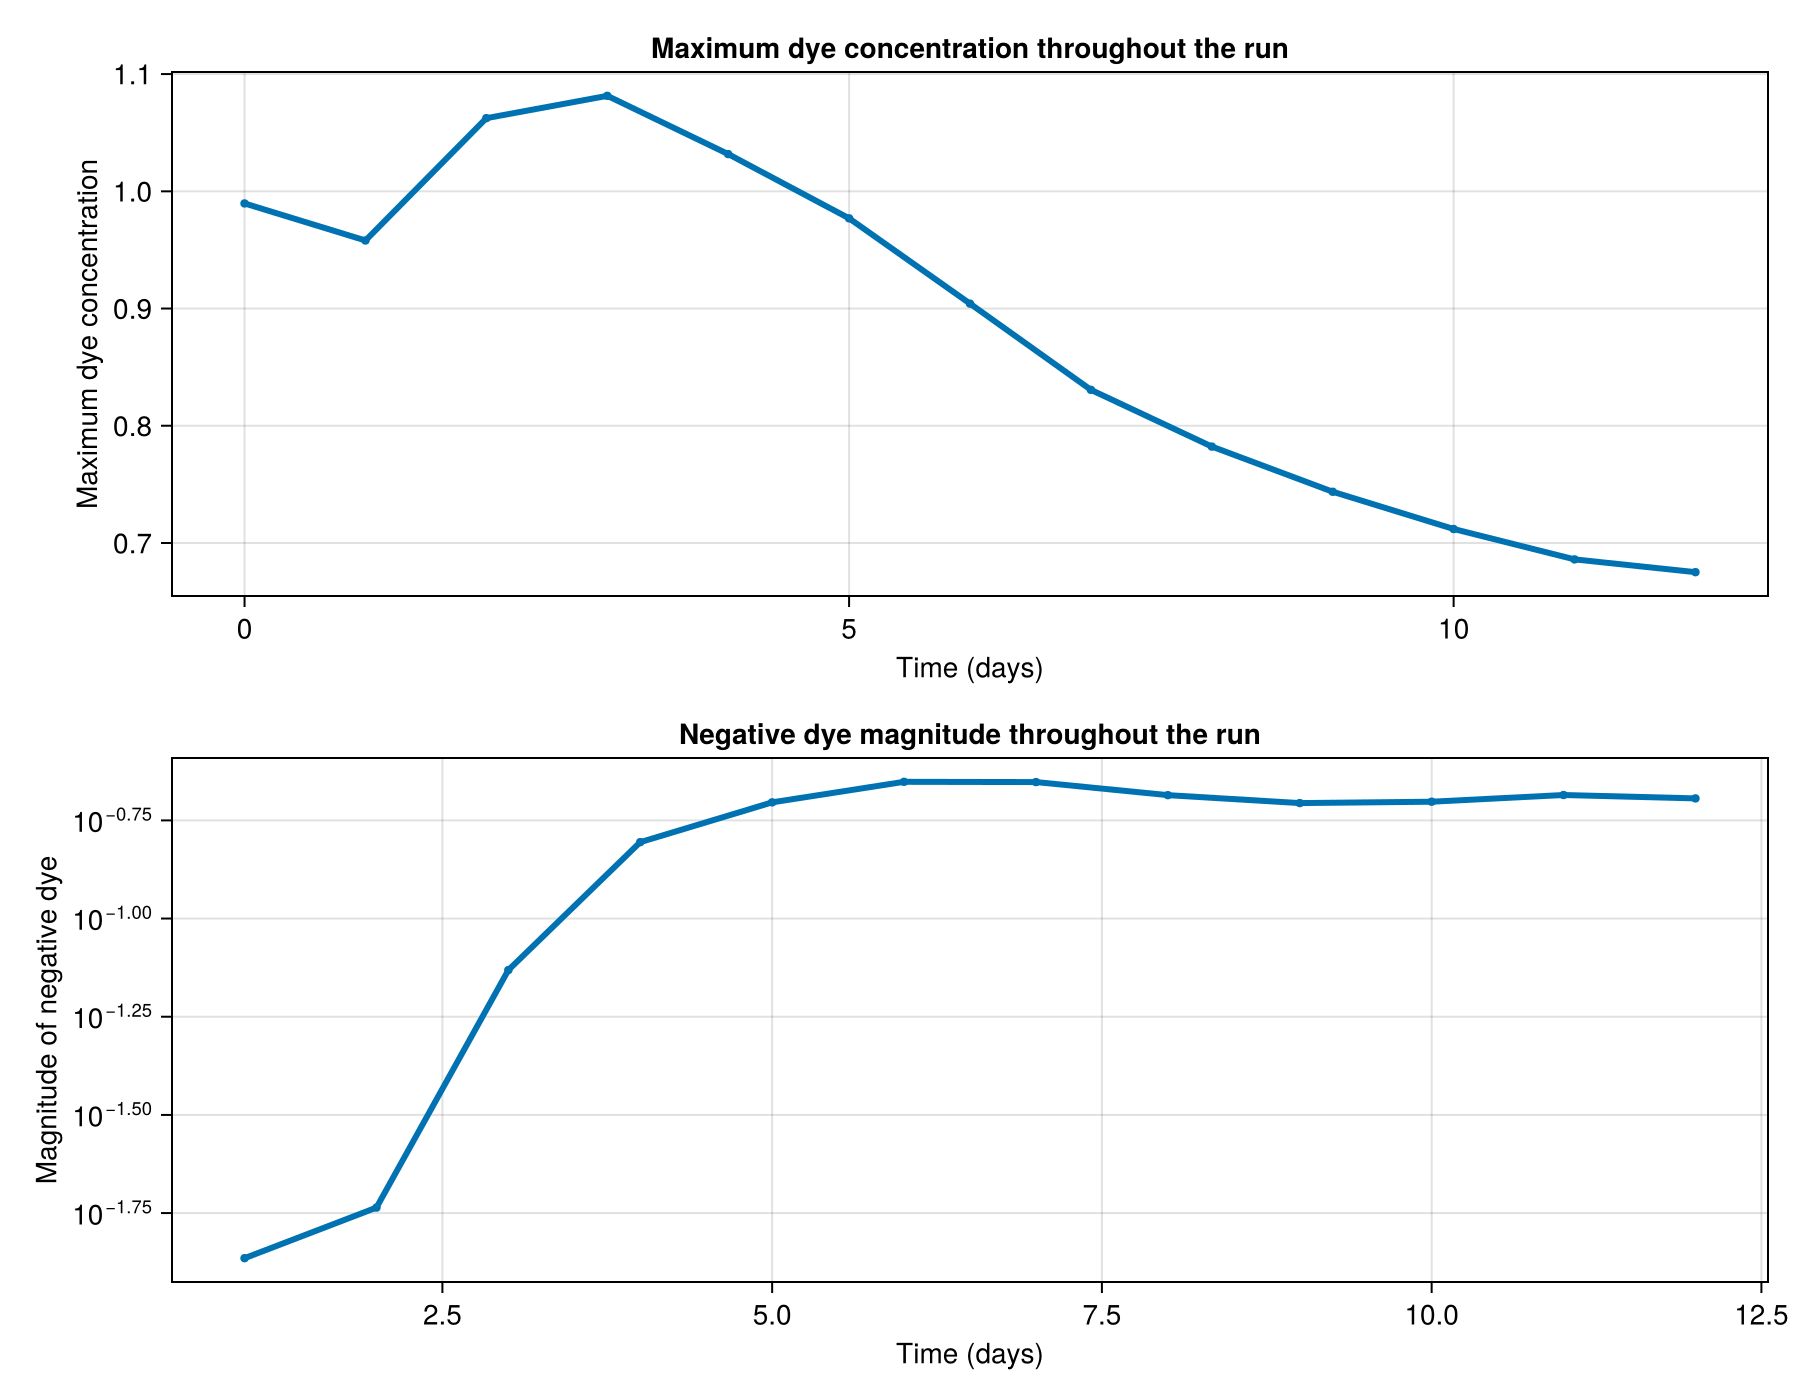

In [23]:
using Oceananigans
using CairoMakie

# load the saved 3d dye output
dye_series = FieldTimeSeries(dye_3d_filename, "dye")

Nt = length(dye_series.times)

time_days = dye_series.times ./ days
minimum_dye = zeros(Float64, Nt)
maximum_dye = zeros(Float64, Nt)

for n in 1:Nt
    dye_snapshot = Array(interior(dye_series[n]))

    minimum_dye[n] = minimum(dye_snapshot)
    maximum_dye[n] = maximum(dye_snapshot)
end

# magnitude of the negative dye values
negative_dye_amount = max.(-minimum_dye, 0)

fig = Figure(size = (900, 700))

ax1 = Axis(
    fig[1, 1],
    xlabel = "Time (days)",
    ylabel = "Maximum dye concentration",
    title = "Maximum dye concentration throughout the run"
)

lines!(
    ax1,
    time_days,
    maximum_dye;
    linewidth = 3
)

scatter!(
    ax1,
    time_days,
    maximum_dye;
    markersize = 6
)

ax2 = Axis(
    fig[2, 1],
    xlabel = "Time (days)",
    ylabel = "Magnitude of negative dye",
    title = "Negative dye magnitude throughout the run",
    yscale = log10
)

# avoid plotting exact zeros on a logarithmic axis
positive_negative_indices = findall(negative_dye_amount .> 0)

lines!(
    ax2,
    time_days[positive_negative_indices],
    negative_dye_amount[positive_negative_indices];
    linewidth = 3
)

scatter!(
    ax2,
    time_days[positive_negative_indices],
    negative_dye_amount[positive_negative_indices];
    markersize = 6
)

save("amazon_$(output_tag)_dye_extrema.png", fig)

fig